In [1]:
from sklearn.linear_model import Lasso, Ridge
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

# 設定中文顯示，載入字體: msjh.ttc (微軟正黑體)
font_path = 'msjh.ttc'
font_prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False    # 避免坐標軸負號顯示問題

In [2]:
np.random.seed(42)
# 生成資料
np.random.seed(42)
m = 100  # 筆數
X = 10 * np.random.rand(m, 1) - 5  # 隨機產生m筆X值
y = 0.5 * X ** 2 - X + 2 + 3 * np.random.randn(m, 1)  # 根據二次方程式計算y值

In [3]:
from sklearn.model_selection import train_test_split
# 使用 train_test_split 將資料分為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [4]:
X_new = np.linspace(-5, 5, 100).reshape(100, 1)
def plot_model(model_class, alphas, **model_kwargs):
    plt.scatter(X_train, y_train, color="blue", label="training set", alpha=0.7, s=15)
    plt.scatter(X_test, y_test, color="green", label="test set", alpha=0.7, s=15)

    for alpha, style in zip(alphas, ("k:", "g--", "r-")):
        if alpha > 0:
            model = model_class(alpha, **model_kwargs)
        else:
            model = LinearRegression()
        model = make_pipeline(
            PolynomialFeatures(degree=50, include_bias=False),
            StandardScaler(),
            model)
        model.fit(X_train, y_train)
        y_new_regul = model.predict(X_new)
        plt.plot(X_new, y_new_regul, style, linewidth=2,
                 label=fr"$\alpha = {alpha}$")
    plt.legend(loc="upper left")
    plt.xlabel("$x_1$")
    plt.axis([-5, 5, -3, 20])
    plt.grid()
    return model

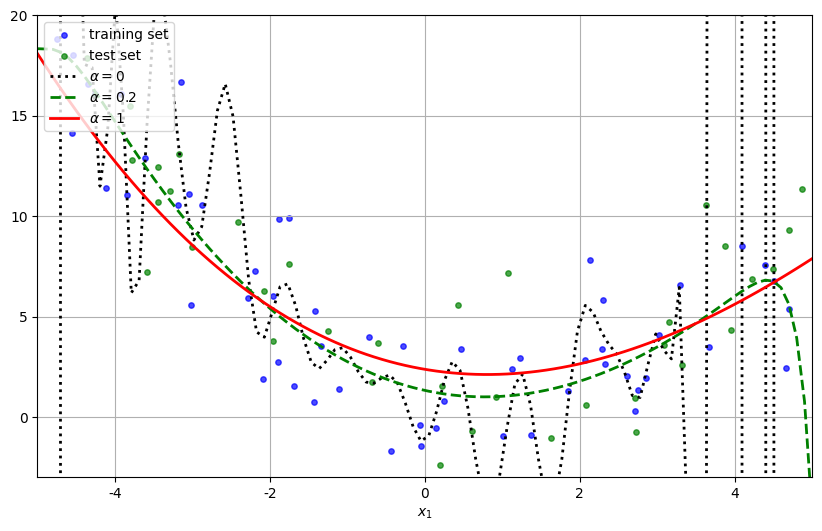

In [5]:
plt.figure(figsize=(10, 6))
lasso_model = plot_model(Lasso, alphas=(0, 0.2, 1), random_state=42)
plt.show()

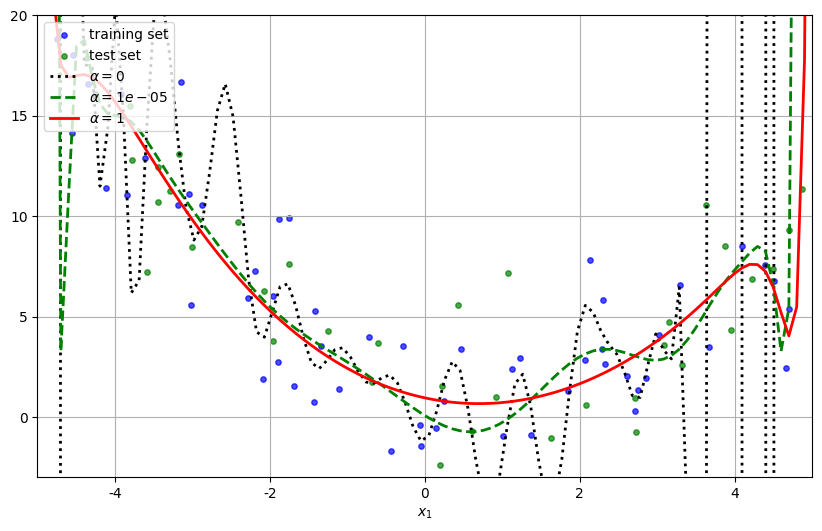

In [ ]:
plt.figure(figsize=(10, 6))
ridge_model = plot_model(Ridge, alphas=(0, 10**-5, 1), random_state=42)
plt.show()

In [7]:
print("Lasso model coefficients:")
print(lasso_model.named_steps['lasso'].coef_)

print("\nRidge model coefficients:")
print(ridge_model.named_steps['ridge'].coef_)

Lasso model coefficients:
[-1.83980412  3.04324921 -0.65051795  0.         -0.          0.
 -0.          0.         -0.          0.         -0.          0.
 -0.          0.         -0.          0.         -0.          0.
 -0.          0.         -0.          0.         -0.          0.
 -0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.         -0.         -0.         -0.
 -0.         -0.        ]

Ridge model coefficients:
[-2.3410835   4.40413734 -0.82412456  0.64689599 -0.20584168 -0.02824383
  0.16312203 -0.07452496  0.27123257 -0.04881095  0.23371692 -0.04898825
  0.14366989 -0.079468    0.04968735 -0.12815032 -0.02827605 -0.1824201
 -0.08464499 -0.23251368 -0.12017085 -0.27189713 -0.13799175 -0.29679944
 -0.14183248 -0.30554042 -0.135231   -0.29789498 -0.12124347 -0.27457895
 -0.10236907 -0.23686834 -0.08057296 

In [8]:
from sklearn.metrics import mean_squared_error

# Lasso
y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))

# Ridge
y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)
rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))

print(f"Lasso RMSE (train): {rmse_train_lasso:.3f}")
print(f"Lasso RMSE (test): {rmse_test_lasso:.3f}")
print(f"Ridge RMSE (train): {rmse_train_ridge:.3f}")
print(f"Ridge RMSE (test): {rmse_test_ridge:.3f}")

Lasso RMSE (train): 3.094
Lasso RMSE (test): 2.794
Ridge RMSE (train): 2.651
Ridge RMSE (test): 5.222


In [11]:
x = [3, 2, 5]
poly_features = make_pipeline(PolynomialFeatures(degree=3, include_bias=False))
X_poly = poly_features.fit_transform(np.array(x).reshape(-1, 1))
print("\nPolynomial features (degree=3) for x = [1, 3, 5]:")
print(X_poly)


Polynomial features (degree=3) for x = [1, 3, 5]:
[[  3.   9.  27.]
 [  2.   4.   8.]
 [  5.  25. 125.]]
